import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [39]:
df=pd.read_excel("/kaggle/input/electriciiity/usElectricity.xlsx")
df

,Date,Electricty
0,1973-01-01,160218
1,1973-02-01,161244
2,1973-03-01,148138
3,1973-04-01,142312
4,1973-05-01,152467
...,...,...
391,2005-08-01,308812
392,2005-09-01,368439
393,2005-10-01,343229
394,2005-11-01,361472


<Axes: xlabel='Date'>

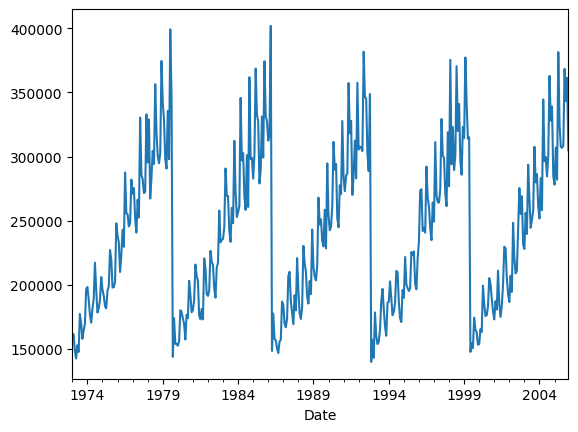

In [40]:
df.index = pd.to_datetime(df['Date'], format= '%Y, %m, %d')
consom = df['Electricty'] 
consom.plot()

In [41]:
# Prétraiter les données
scaler = MinMaxScaler(feature_range=(0, 1))
df['Electricty'] = scaler.fit_transform(df['Electricty'].values.reshape(-1, 1))

In [42]:
# Création des séquences temporelles

def create_sequences(df, seq_length):
    X  = []
    y= []
    for i in range(len(df) - seq_length):
        X.append(df[i:i+seq_length])
        y.append(df[i+seq_length])
    return np.array(X), np.array(y)

In [43]:
# Définition de la longueur de la séquence temporelle
seq_length = 12

In [45]:
# Création des séquences temporelles
X, y = create_sequences(df['Electricty'].values, seq_length)

In [46]:
# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
# Création et entraînement le modèle LSTM
model = Sequential()
model.add(LSTM(64, input_shape=(seq_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=2)

Epoch 1/50


/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 - 2s - 175ms/step - loss: 0.1451
Epoch 2/50
10/10 - 0s - 8ms/step - loss: 0.0389
Epoch 3/50
10/10 - 0s - 14ms/step - loss: 0.0321
Epoch 4/50
10/10 - 0s - 8ms/step - loss: 0.0320
Epoch 5/50
10/10 - 0s - 8ms/step - loss: 0.0300
Epoch 6/50
10/10 - 0s - 8ms/step - loss: 0.0290
Epoch 7/50
10/10 - 0s - 8ms/step - loss: 0.0282
Epoch 8/50
10/10 - 0s - 14ms/step - loss: 0.0278
Epoch 9/50
10/10 - 0s - 15ms/step - loss: 0.0273
Epoch 10/50
10/10 - 0s - 13ms/step - loss: 0.0268
Epoch 11/50
10/10 - 0s - 8ms/step - loss: 0.0259
Epoch 12/50
10/10 - 0s - 14ms/step - loss: 0.0260
Epoch 13/50
10/10 - 0s - 8ms/step - loss: 0.0266
Epoch 14/50
10/10 - 0s - 8ms/step - loss: 0.0259
Epoch 15/50
10/10 - 0s - 8ms/step - loss: 0.0240
Epoch 16/50
10/10 - 0s - 14ms/step - loss: 0.0239
Epoch 17/50
10/10 - 0s - 8ms/step - loss: 0.0226
Epoch 18/50
10/10 - 0s - 14ms/step - loss: 0.0224
Epoch 19/50
10/10 - 0s - 14ms/step - loss: 0.0220
Epoch 20/50
10/10 - 0s - 8ms/step - loss: 0.0233
Epoch 21/50
10/10 - 0s - 13ms/

In [48]:
# Évalution du modèle
train_loss = model.evaluate(X_train, y_train, verbose=0)
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Train Loss: {train_loss}, Test Loss: {test_loss}')

Train Loss: 0.016472306102514267, Test Loss: 0.014727260917425156


In [49]:
# Faire des prédictions
predictions = model.predict(X_test)
predictions

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


array([[0.45700392],
       [0.22480598],
       [0.49329743],
       [0.22304815],
       [0.68692213],
       [0.6571461 ],
       [0.48383754],
       [0.50417775],
       [0.5178133 ],
       [0.16167617],
       [0.19978358],
       [0.5491857 ],
       [0.47450316],
       [0.32123592],
       [0.41555595],
       [0.28089398],
       [0.08540175],
       [0.5646688 ],
       [0.6201448 ],
       [0.22435674],
       [0.4887138 ],
       [0.5247058 ],
       [0.22522397],
       [0.20076087],
       [0.23087361],
       [0.6837725 ],
       [0.6246576 ],
       [0.49428138],
       [0.14506978],
       [0.57635117],
       [0.3853821 ],
       [0.34950683],
       [0.20489395],
       [0.18178883],
       [0.7212468 ],
       [0.20348185],
       [0.3066353 ],
       [0.5834668 ],
       [0.43867153],
       [0.6913925 ],
       [0.17124969],
       [0.5246169 ],
       [0.48031402],
       [0.1647499 ],
       [0.56725127],
       [0.2823901 ],
       [0.45189103],
       [0.189

In [51]:
# Inverser la mise à l'échelle des prédictions
predictions1 = scaler.inverse_transform(predictions)

In [52]:
print(predictions1)

[[259501.8 ]
 [198575.62]
 [269024.8 ]
 [198114.38]
 [319829.8 ]
 [312016.9 ]
 [266542.66]
 [271879.72]
 [275457.5 ]
 [182011.05]
 [192010.02]
 [283689.28]
 [264093.4 ]
 [223877.78]
 [248626.31]
 [213292.48]
 [161997.48]
 [287751.88]
 [302308.2 ]
 [198457.75]
 [267822.12]
 [277266.06]
 [198685.3 ]
 [192266.45]
 [200167.7 ]
 [319003.4 ]
 [303492.28]
 [269283.  ]
 [177653.7 ]
 [290817.2 ]
 [240709.02]
 [231295.75]
 [193350.9 ]
 [187288.39]
 [328836.22]
 [192980.39]
 [220046.73]
 [292684.28]
 [254691.58]
 [321002.78]
 [184523.03]
 [277242.72]
 [265618.1 ]
 [182817.56]
 [288429.5 ]
 [213685.06]
 [258160.23]
 [189255.27]
 [202417.72]
 [311232.56]
 [241166.36]
 [163691.05]
 [180128.78]
 [293717.3 ]
 [300318.66]
 [303722.06]
 [323757.34]
 [165390.88]
 [187694.1 ]
 [211350.03]
 [297737.94]
 [202397.84]
 [188340.61]
 [221977.84]
 [170247.72]
 [288181.47]
 [271540.  ]
 [307493.25]
 [293945.66]
 [188461.9 ]
 [201637.5 ]
 [288315.34]
 [215551.75]
 [192414.44]
 [304843.38]
 [178354.78]
 [189732.75]

In [53]:
train_predictions = model.predict(X_train).flatten()
train_results = pd.DataFrame(data={'Train Predictions':train_predictions, 'Actuals':y_train})
train_results

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,Train Predictions,Actuals
0,0.196884,0.198594
1,0.214695,0.191163
2,0.592708,0.923160
3,0.230139,0.278083
4,0.131628,0.059450
...,...,...
302,0.108241,0.054210
303,0.351504,0.355956
304,0.456850,0.581465
305,0.461315,0.336180


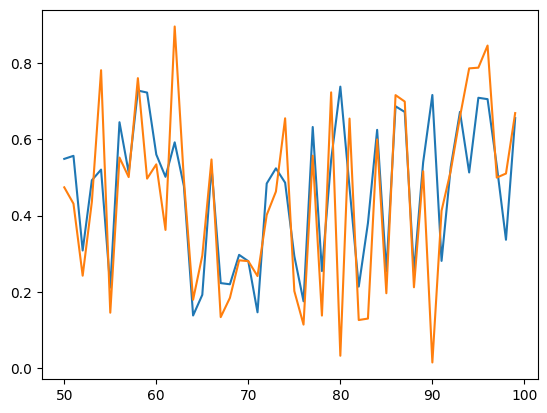

In [54]:
import matplotlib.pyplot as plt
plt.plot(train_results['Train Predictions'][50:100])
plt.plot(train_results['Actuals'][50:100])